In [1]:
from datasets import load_dataset

ds = load_dataset("jxie/flickr8k")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [2]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})


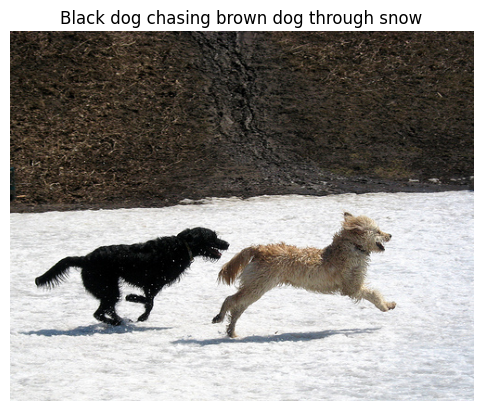

In [3]:
import matplotlib.pyplot as plt

example = ds["train"][0]

image = example["image"]
caption_1 = example["caption_1"] # 5 total captions

plt.imshow(image)
plt.axis("off")
plt.title(caption_1)
plt.show()

In [42]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler
import matplotlib.pyplot as plt

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # converts to tensor for a model
])

example = ds["train"][0]

image = example["image"]

image_tensor = transform(image)

print(image_tensor.shape)

torch.Size([3, 224, 224])


# Using RNNs for image captioning

Desired architecture: CNN for encoder, LSTM for decoder, cross entropy loss

What ResNet? ResNet50

## The ResNet architecture is comprised of bottleneck blocks

In [7]:
class Bottleneck(nn.Module):
  def __init__(self, in_channels, out_channels, stride, expansion=4):
    super().__init__()

    # The expansion parameter for encoder's sake
    self.expansion = expansion

    self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            bias=False
        )

    self.batchnorm1 = nn.BatchNorm2d(out_channels)

    self.relu = nn.ReLU(inplace=True) # saves memory

    self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride = stride,
            padding = 1,
            bias=False
        )

    self.batchnorm2 = nn.BatchNorm2d(out_channels)

    self.conv3 = nn.Conv2d(
            out_channels,
            out_channels * self.expansion,
            kernel_size=1,
            bias=False
        )

    self.batchnorm3 = nn.BatchNorm2d(out_channels * self.expansion)

    self.downsample = nn.Conv2d(
            in_channels,
            out_channels * self.expansion,
            kernel_size=1,
            stride=stride,
            bias=False
        )

  def forward(self, x):
    input = x

    x = self.conv1(x)
    x = self.batchnorm1(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.batchnorm2(x)
    x = self.relu(x)

    x = self.conv3(x)
    x = self.batchnorm3(x)

    residual = self.downsample(input)
    residual = self.batchnorm3(residual)
    x += residual
    output = self.relu(x)

    return output


In [8]:
class ResNet50(nn.Module):

  def __init__(self, out_classes):
    super().__init__()

    self.in_channels = 64

    # stage 1
    self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=7,
            stride=2,
            padding = 3,
            bias =False
        )
    self.bn1 = nn.BatchNorm2d(64)

    self.relu = nn.ReLU(inplace=True)

    self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )

    self.layer1 = self._make_layer(64, 3)
    self.layer2 = self._make_layer(128, 4, 2)
    self.layer3 = self._make_layer(256, 6, 2)
    self.layer4 = self._make_layer(512, 3, 2)

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(2048, out_classes) # 1000 imagenet classes

  def _make_layer(self, out_channels, blocks, stride=1):
    layers = [Bottleneck(self.in_channels, out_channels, stride)]

    self.in_channels = out_channels * 4

    for _ in range(blocks-1):
      layers.append(Bottleneck(self.in_channels, out_channels, stride))

    return nn.Sequential(*layers)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)

    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    out = self.fc(x)

    return out


In [9]:
resnet_model_cifar_10 = ResNet50(10)

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [74]:
def train(model, optimizer, criterion, dataloader, epochs=10):
  model.train()

  losses = []
  for epoch in range(epochs):
    epoch_loss = []
    for batch in dataloader:

      train_x = batch[0]
      train_y = batch[1]

      output = model(train_x)
      loss = criterion(output, train_y)

      optimizer.zero_grad()
      loss.backward()

      optimizer.step()

      epoch_loss += [loss]

      print(f"Batch loss: {loss}")

    losses += [epoch_loss]

    print(f"EPOCH {epoch} loss: {losses[-1][-1]}")
    PATH = "/content/drive/MyDrive/trained_cifar10_model.pt"

    torch.save(
        model.state_dict(),
        PATH
    )

    print(f"Model state dict saved to {PATH} after epoch {epoch}")

## Use CIFAR-10 to test ResNet50

In [11]:
train_cifar10 = datasets.CIFAR10(root='./data', download=True, train=True, transform=transform)
test_cifar10 = datasets.CIFAR10(root='./data', download=True, train=False, transform=transform)

100%|██████████| 170M/170M [00:06<00:00, 25.9MB/s]


In [12]:
trainloader = torch.utils.data.DataLoader(train_cifar10, batch_size=32, shuffle=True, num_workers=0)

In [13]:
print(next(iter(trainloader))[0].shape) # train batch shape

print(next(iter(trainloader))[1].shape) # test batch shape

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [75]:
optimizer = torch.optim.Adam(resnet_model_cifar_10.parameters(), lr=1e-4)
ce_loss = torch.nn.CrossEntropyLoss()

train(resnet_model_cifar_10, optimizer, ce_loss, trainloader)

Batch loss: 1.9676212072372437
Batch loss: 1.9647409915924072
Batch loss: 1.9217857122421265
Batch loss: 1.7814011573791504
Batch loss: 1.8679286241531372
Batch loss: 1.723042368888855
Batch loss: 1.9264909029006958
Batch loss: 1.7551000118255615
Batch loss: 1.6632579565048218
Batch loss: 2.142557144165039
Batch loss: 2.009249210357666
Batch loss: 1.9288966655731201
Batch loss: 2.119723081588745
Batch loss: 2.1149322986602783
Batch loss: 1.898729920387268
Batch loss: 1.7970890998840332
Batch loss: 2.0364270210266113
Batch loss: 2.276920795440674
Batch loss: 2.1935231685638428
Batch loss: 1.8525807857513428
Batch loss: 1.9187343120574951
Batch loss: 1.8216750621795654
Batch loss: 1.8458507061004639
Batch loss: 2.08426833152771
Batch loss: 2.0910847187042236
Batch loss: 1.9774971008300781
Batch loss: 1.7488099336624146
Batch loss: 1.7793620824813843
Batch loss: 1.844642162322998
Batch loss: 1.7053582668304443
Batch loss: 1.9443025588989258
Batch loss: 2.055433750152588
Batch loss: 2.1081

KeyboardInterrupt: 

In [22]:
PATH = "/content/drive/MyDrive/trained_cifar10_model.pt"

torch.save(
    resnet_model_cifar_10.state_dict(),
    PATH
)

In [46]:
def predict(idx):
  resnet_model_cifar_10.eval()

  with torch.no_grad():
      out = resnet_model_cifar_10(test_cifar10[idx][0].unsqueeze(0))

  return out

In [51]:
pred = np.argmax(predict(1)).item()
print(pred)
print(test_cifar10.classes[pred])

9
truck


In [43]:
def show_im(idx):
  image, label = test_cifar10[idx]

  # image is a tensor: (3, 32, 32)
  # matplotlib expects: (32, 32, 3)

  plt.imshow(image.permute(1, 2, 0))
  plt.title(f"Label: {label}")
  plt.axis("off")
  plt.show()

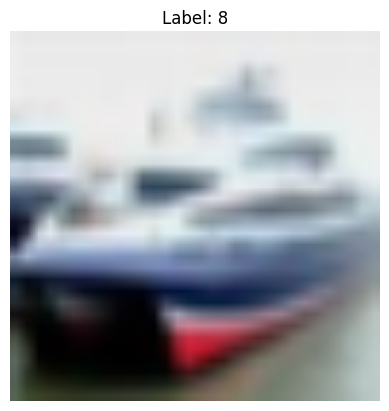

In [52]:
show_im(1)

## This is a wrong prediction... the model should be trained for longer besides the 1 epoch weights saved

In [76]:
## Load from model weights

model = ResNet50(out_classes=10)

model.load_state_dict(
    torch.load(PATH)
);

model.eval();

In [61]:
def predict_loaded(idx):
  model.eval()

  with torch.no_grad():
      out = model(test_cifar10[idx][0].unsqueeze(0))

  return out

In [77]:
pred = np.argmax(predict_loaded(1)).item()
print(pred)
print(test_cifar10.classes[pred])

9
truck


In [78]:
model.eval()
model(test_cifar10[1][0].unsqueeze(0))


tensor([[-2.1901, -1.3852, -1.7191, -1.0577, -1.7569, -1.9873, -2.8400, -0.6865,
         -2.0327, -0.4846]], grad_fn=<AddmmBackward0>)

In [70]:
resnet_model_cifar_10.eval()
resnet_model_cifar_10(test_cifar10[1][0].unsqueeze(0))


tensor([[-1.6422,  0.0327, -1.6026, -0.5719, -1.5471, -1.0653, -2.3940, -0.5678,
         -1.0200,  0.0564]], grad_fn=<AddmmBackward0>)